# Chapter 10 Python Lab  
## Chain Rule, Jacobians, and Automatic Differentiation

This lab accompanies **Chapter 10: Chain Rule, Jacobians, and Automatic Differentiation**.

The main idea is that complicated functions are built by composing simpler functions.  
The derivative of a composition is governed by the **chain rule**.

For scalar functions,

$$
\frac{d}{dt} f(x(t),y(t))
=
f_x(x(t),y(t))x'(t)+f_y(x(t),y(t))y'(t).
$$

For vector-valued functions, the chain rule is written with **Jacobians**:

$$
J_{F\circ G}(u)=J_F(G(u))J_G(u).
$$

In modern computation, the same idea powers **automatic differentiation**, the engine behind gradient-based optimization and neural networks.

This lab uses Python to explore:

- scalar chain rules,
- paths through scalar fields,
- Jacobian matrices,
- composition of vector-valued functions,
- finite-difference Jacobian checks,
- forward-mode automatic differentiation using dual numbers,
- reverse-mode automatic differentiation on computational graphs,
- and backpropagation for a small model.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. compute derivatives of composed functions using the chain rule;
2. interpret $df/dt=\nabla f\cdot \mathbf r'(t)$ along a path;
3. compute Jacobian matrices for vector-valued functions;
4. verify the matrix chain rule numerically;
5. use finite differences to check analytic derivatives;
6. understand the difference between forward-mode and reverse-mode automatic differentiation;
7. implement a simple dual-number class for forward-mode AD;
8. implement a small reverse-mode AD engine;
9. compute gradients for loss functions;
10. connect the calculus chain rule with backpropagation in machine learning.

## Source note

This notebook was generated from the uploaded Chapter 10 QMD file.  
The extracted early headings from the source file include:

- Chapter overview
- Learning goals
- 10.1 Why composition matters
- 10.2 Chain rule along a curve
- Worked example 10.1: Chain rule along a curve
- Surface z = f(x,y)
- A numerical check
- 10.3 The tree form of the chain rule
- Worked example 10.2: Two-parameter chain rule
- 10.4 Jacobian matrices
- Worked example 10.3: A Jacobian matrix
- 10.5 The Jacobian as a local linear map

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

def norm(v):
    return np.linalg.norm(v)

def unit(v, tol=1e-12):
    v = np.asarray(v, dtype=float)
    n = norm(v)
    if n < tol:
        raise ValueError("The zero vector has no unit direction.")
    return v / n

def central_diff_1d(g, t, h=1e-5):
    return (g(t + h) - g(t - h)) / (2*h)

def finite_gradient_2d(f, x, y, h=1e-5):
    fx = (f(x + h, y) - f(x - h, y)) / (2*h)
    fy = (f(x, y + h) - f(x, y - h)) / (2*h)
    return np.array([fx, fy], dtype=float)

def finite_jacobian(F, x, h=1e-5):
    """
    Approximate the Jacobian matrix of F at x by central differences.
    F maps R^n to R^m.
    """
    x = np.asarray(x, dtype=float)
    y0 = np.asarray(F(x), dtype=float)
    m = y0.size
    n = x.size
    J = np.zeros((m, n), dtype=float)
    for j in range(n):
        step = np.zeros_like(x)
        step[j] = h
        J[:, j] = (np.asarray(F(x + step)) - np.asarray(F(x - step))) / (2*h)
    return J

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def plot_contours_with_path(f, x_path, y_path, t_values,
                            xmin=-3, xmax=3, ymin=-3, ymax=3,
                            title="Scalar field and path"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=300)
    Z = f(X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=18)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.plot(x_path(t_values), y_path(t_values), linewidth=2, marker="o", markersize=2)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()

print("Setup complete.")

Setup complete.


---

# Part I. Chain rule along a path

Let

$$
z=f(x,y)
$$

and suppose

$$
x=x(t),\qquad y=y(t).
$$

Then the composite function

$$
z(t)=f(x(t),y(t))
$$

has derivative

$$
\frac{dz}{dt}
=
f_x(x(t),y(t))x'(t)+f_y(x(t),y(t))y'(t).
$$

In vector notation, if

$$
\mathbf r(t)=\langle x(t),y(t)\rangle,
$$

then

$$
\frac{d}{dt}f(\mathbf r(t))
=
\nabla f(\mathbf r(t))\cdot \mathbf r'(t).
$$

## 1. A scalar field and a path

Consider

$$
f(x,y)=x^2y+\sin y
$$

and the path

$$
x(t)=\cos t,\qquad y(t)=1+\sin t.
$$

The composite is

$$
z(t)=f(\cos t,1+\sin t).
$$

In [2]:
def f_scalar(x, y):
    return x**2 * y + np.sin(y)

def fx_scalar(x, y):
    return 2*x*y

def fy_scalar(x, y):
    return x**2 + np.cos(y)

def x_path(t):
    return np.cos(t)

def y_path(t):
    return 1 + np.sin(t)

def dx_path(t):
    return -np.sin(t)

def dy_path(t):
    return np.cos(t)

def z_composite(t):
    return f_scalar(x_path(t), y_path(t))

def dzdt_chain(t):
    x = x_path(t)
    y = y_path(t)
    return fx_scalar(x, y)*dx_path(t) + fy_scalar(x, y)*dy_path(t)

t0 = 0.7

print("t0 =", t0)
print("x(t0), y(t0) =", x_path(t0), y_path(t0))
print("z(t0) =", z_composite(t0))
print("dz/dt by chain rule =", dzdt_chain(t0))
print("dz/dt by finite difference =", central_diff_1d(z_composite, t0))

t0 = 0.7
x(t0), y(t0) = 0.7648421872844885 1.644217687237691
z(t0) = 1.9591461974364588
dz/dt by chain rule = -1.228979076027571
dz/dt by finite difference = -1.2289790758845953


## 2. Plot the composite function and its derivative

The scalar field lives in the $xy$-plane, but the path turns it into a one-variable function $z(t)$.

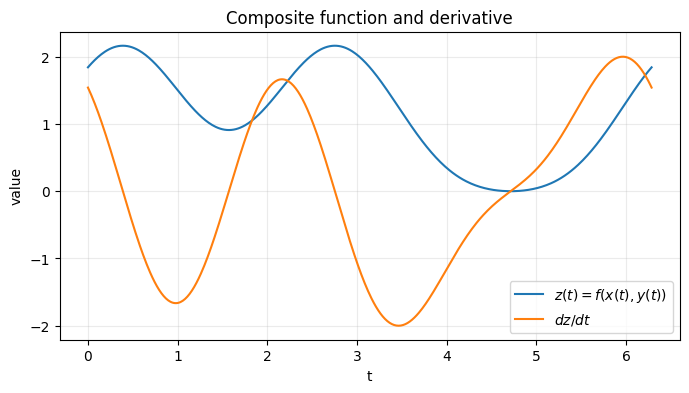

In [3]:
t = np.linspace(0, 2*np.pi, 500)
z_values = z_composite(t)
dz_values = dzdt_chain(t)

plt.figure(figsize=(8, 4))
plt.plot(t, z_values, label=r"$z(t)=f(x(t),y(t))$")
plt.plot(t, dz_values, label=r"$dz/dt$")
plt.xlabel("t")
plt.ylabel("value")
plt.title("Composite function and derivative")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 3. Visualize the path on contour lines

The derivative $dz/dt$ measures how quickly the path crosses the contour map of $f$.

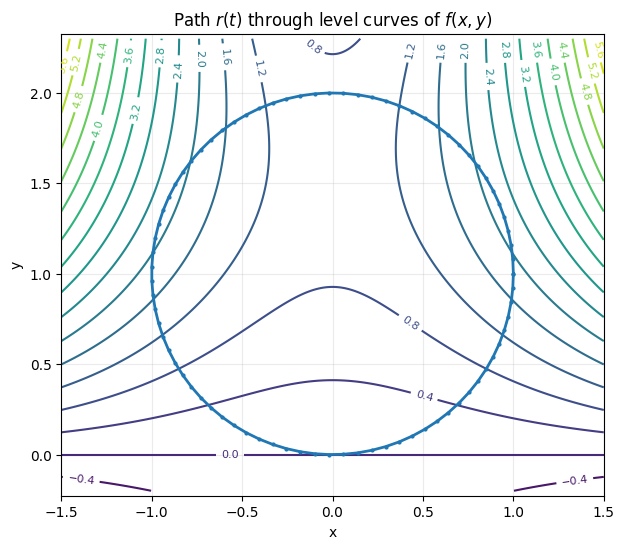

In [41]:
t_values = np.linspace(0, 2*np.pi, 80)

plot_contours_with_path(
    f_scalar,
    x_path,
    y_path,
    t_values,
    xmin=-1.5, xmax=1.5, ymin=-0.2, ymax=2.3,
    title=r"Path $r(t)$ through level curves of $f(x,y)$"
)

## 4. Decompose the derivative

The derivative

$$
\frac{dz}{dt}
=
\nabla f(\mathbf r(t))\cdot\mathbf r'(t)
$$

is a dot product between:

- the gradient of the field;
- the velocity of the path.

If the path moves along a level curve, the dot product is zero.

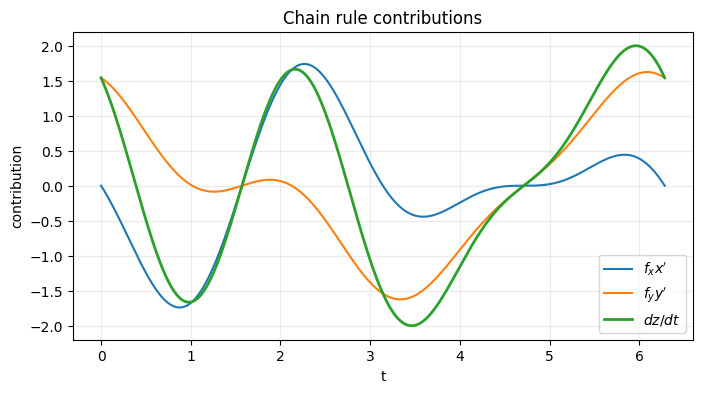

In [5]:
t = np.linspace(0, 2*np.pi, 500)

grad_x = fx_scalar(x_path(t), y_path(t))
grad_y = fy_scalar(x_path(t), y_path(t))
vel_x = dx_path(t)
vel_y = dy_path(t)

component_x = grad_x * vel_x
component_y = grad_y * vel_y

plt.figure(figsize=(8, 4))
plt.plot(t, component_x, label=r"$f_x x'$")
plt.plot(t, component_y, label=r"$f_y y'$")
plt.plot(t, component_x + component_y, linewidth=2, label=r"$dz/dt$")
plt.xlabel("t")
plt.ylabel("contribution")
plt.title("Chain rule contributions")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Guided task 1

Change the path to

$$
x(t)=t,\qquad y(t)=t^2
$$

and compute

$$
\frac{d}{dt}f(t,t^2)
$$

at $t=1$ using the chain rule and finite differences.

In [6]:
def x_path2(t):
    return t

def y_path2(t):
    return t**2

def dx_path2(t):
    return np.ones_like(t)

def dy_path2(t):
    return 2*t

def z_composite2(t):
    return f_scalar(x_path2(t), y_path2(t))

def dzdt_chain2(t):
    x = x_path2(t)
    y = y_path2(t)
    return fx_scalar(x, y)*dx_path2(t) + fy_scalar(x, y)*dy_path2(t)

t0 = 1.0
print("Chain rule derivative:", dzdt_chain2(t0))
print("Finite-difference derivative:", central_diff_1d(z_composite2, t0))

Chain rule derivative: 5.0806046117362795
Finite-difference derivative: 5.080604611895634


---

# Part II. Chain rule for functions of several intermediate variables

A common form is

$$
w=f(x,y,z),
$$

where

$$
x=x(s,t),\qquad y=y(s,t),\qquad z=z(s,t).
$$

Then

$$
\frac{\partial w}{\partial s}
=
f_x\frac{\partial x}{\partial s}
+
f_y\frac{\partial y}{\partial s}
+
f_z\frac{\partial z}{\partial s},
$$

and similarly for $\partial w/\partial t$.

## 5. Two-parameter chain rule

Let

$$
f(x,y,z)=x^2+yz+\sin(xz),
$$

with

$$
x=s+t,\qquad y=st,\qquad z=e^s\cos t.
$$

In [7]:
def f3(x, y, z):
    return x**2 + y*z + np.sin(x*z)

def grad_f3(x, y, z):
    fx = 2*x + z*np.cos(x*z)
    fy = z
    fz = y + x*np.cos(x*z)
    return np.array([fx, fy, fz], dtype=float)

def intermediates(s, t):
    x = s + t
    y = s*t
    z = np.exp(s)*np.cos(t)
    return np.array([x, y, z], dtype=float)

def J_intermediates(s, t):
    # Rows are x, y, z; columns are s, t.
    return np.array([
        [1.0, 1.0],
        [t, s],
        [np.exp(s)*np.cos(t), -np.exp(s)*np.sin(t)]
    ], dtype=float)

def w_st(s, t):
    x, y, z = intermediates(s, t)
    return f3(x, y, z)

def grad_w_chain(s, t):
    x, y, z = intermediates(s, t)
    grad = grad_f3(x, y, z)       # shape (3,)
    J = J_intermediates(s, t)     # shape (3,2)
    return grad @ J               # shape (2,)

s0, t0 = 0.4, 0.7
print("s0,t0 =", (s0, t0))
print("intermediate vector [x,y,z] =", intermediates(s0, t0))
print("gradient of f wrt [x,y,z] =", grad_f3(*intermediates(s0, t0)))
print("Jacobian of intermediates wrt [s,t] =")
print(J_intermediates(s0, t0))
print("gradient of w wrt [s,t] by chain rule =", grad_w_chain(s0, t0))

s0,t0 = (0.4, 0.7)
intermediate vector [x,y,z] = [1.1     0.28    1.14101]
gradient of f wrt [x,y,z] = [2.554247 1.14101  0.621514]
Jacobian of intermediates wrt [s,t] =
[[ 1.       1.     ]
 [ 0.7      0.4    ]
 [ 1.14101 -0.96106]]
gradient of w wrt [s,t] by chain rule = [4.062108 2.413338]


## 6. Finite-difference check for the two-parameter chain rule

In [8]:
def W_vec(u):
    s, t = u
    return np.array([w_st(s, t)])

J_w_num = finite_jacobian(W_vec, np.array([s0, t0]))
grad_num = J_w_num[0]

print("Chain-rule gradient:", grad_w_chain(s0, t0))
print("Finite-difference gradient:", grad_num)
print("Difference:", grad_num - grad_w_chain(s0, t0))

Chain-rule gradient: [4.062108 2.413338]
Finite-difference gradient: [4.062108 2.413338]
Difference: [-0. -0.]


---

# Part III. Jacobian matrices

For a vector-valued function

$$
F:\mathbb R^n\to\mathbb R^m,
$$

the Jacobian matrix is

$$
J_F(x)=
\begin{bmatrix}
\frac{\partial F_1}{\partial x_1} & \cdots & \frac{\partial F_1}{\partial x_n}\\
\vdots & \ddots & \vdots\\
\frac{\partial F_m}{\partial x_1} & \cdots & \frac{\partial F_m}{\partial x_n}
\end{bmatrix}.
$$

It is the matrix of the best linear approximation to $F$ near the point.

## 7. A map from $\mathbb R^2$ to $\mathbb R^2$

Let

$$
F(u,v)=
\begin{bmatrix}
u^2+v\\
e^u\sin v
\end{bmatrix}.
$$

Then

$$
J_F(u,v)=
\begin{bmatrix}
2u & 1\\
e^u\sin v & e^u\cos v
\end{bmatrix}.
$$

In [9]:
def F_uv(x):
    u, v = x
    return np.array([
        u**2 + v,
        np.exp(u)*np.sin(v)
    ], dtype=float)

def J_F_uv(x):
    u, v = x
    return np.array([
        [2*u, 1.0],
        [np.exp(u)*np.sin(v), np.exp(u)*np.cos(v)]
    ], dtype=float)

p = np.array([0.5, 1.2])
J_exact = J_F_uv(p)
J_num = finite_jacobian(F_uv, p)

print("Point:", p)
print("Exact Jacobian:")
print(J_exact)
print("Finite-difference Jacobian:")
print(J_num)
print("Difference:")
print(J_num - J_exact)

Point: [0.5 1.2]
Exact Jacobian:
[[1.       1.      ]
 [1.536673 0.597427]]
Finite-difference Jacobian:
[[1.       1.      ]
 [1.536673 0.597427]]
Difference:
[[-0.  0.]
 [ 0. -0.]]


## 8. Local linear approximation of a vector-valued function

Near $p$,

$$
F(p+\Delta p)\approx F(p)+J_F(p)\Delta p.
$$

In [10]:
p = np.array([0.5, 1.2])
J = J_F_uv(p)
F0 = F_uv(p)

deltas = [
    np.array([0.01, -0.02]),
    np.array([0.05, 0.04]),
    np.array([0.15, -0.10]),
]

for d in deltas:
    true_change = F_uv(p + d) - F0
    linear_change = J @ d
    print("delta =", d)
    print("  true change   =", true_change)
    print("  linear change =", linear_change)
    print("  error         =", linear_change - true_change)
    print()

delta = [ 0.01 -0.02]
  true change   = [-0.0099    0.003066]
  linear change = [-0.01      0.003418]
  error         = [-0.0001    0.000353]

delta = [0.05 0.04]
  true change   = [0.0925  0.10261]
  linear change = [0.09     0.100731]
  error         = [-0.0025  -0.00188]

delta = [ 0.15 -0.1 ]
  true change   = [0.0725   0.170471]
  linear change = [0.05     0.170758]
  error         = [-0.0225    0.000287]



## 9. Jacobian as local deformation

A Jacobian maps small input displacement vectors to approximate output displacement vectors.

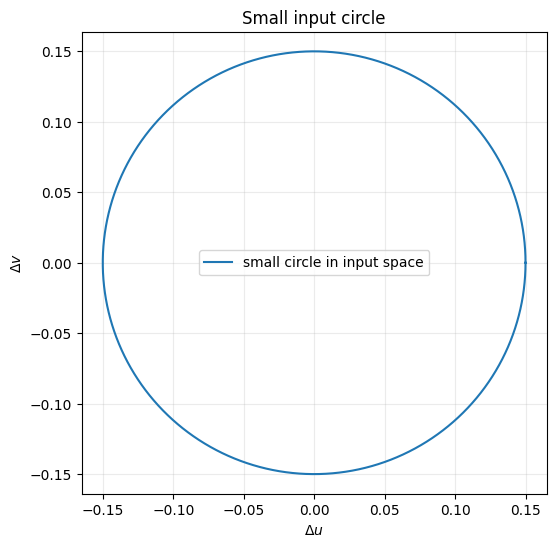

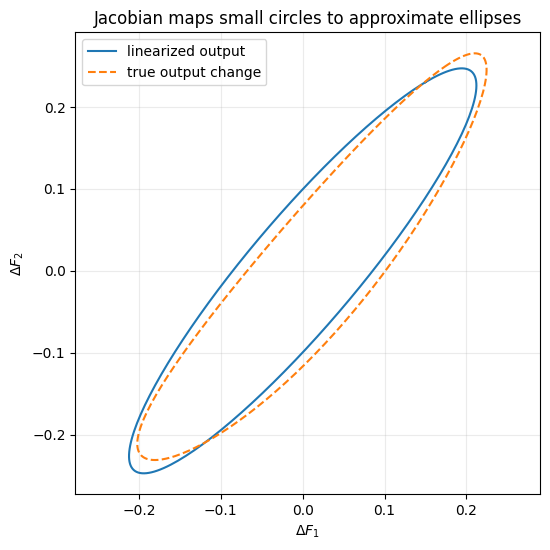

In [11]:
theta = np.linspace(0, 2*np.pi, 200)
radius = 0.15
circle = np.column_stack([radius*np.cos(theta), radius*np.sin(theta)])
ellipse_linear = circle @ J.T
mapped_nonlinear = np.array([F_uv(p + d) - F0 for d in circle])

plt.figure(figsize=(6, 6))
plt.plot(circle[:,0], circle[:,1], label="small circle in input space")
plt.xlabel(r"$\Delta u$")
plt.ylabel(r"$\Delta v$")
plt.title("Small input circle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(ellipse_linear[:,0], ellipse_linear[:,1], label="linearized output")
plt.plot(mapped_nonlinear[:,0], mapped_nonlinear[:,1], linestyle="--", label="true output change")
plt.xlabel(r"$\Delta F_1$")
plt.ylabel(r"$\Delta F_2$")
plt.title("Jacobian maps small circles to approximate ellipses")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Matrix chain rule

If

$$
H=F\circ G,
$$

where

$$
G:\mathbb R^n\to\mathbb R^m,\qquad F:\mathbb R^m\to\mathbb R^k,
$$

then

$$
J_H(x)=J_F(G(x))J_G(x).
$$

The order matters: the Jacobians multiply in the same order as the local linear maps.

## 10. Composition example

Let

$$
G(s,t)=
\begin{bmatrix}
s+t\\
st
\end{bmatrix}
$$

and

$$
F(u,v)=
\begin{bmatrix}
u^2+v\\
e^u\sin v
\end{bmatrix}.
$$

Then

$$
H(s,t)=F(G(s,t)).
$$

In [12]:
def G_st(x):
    s, t = x
    return np.array([s + t, s*t], dtype=float)

def J_G_st(x):
    s, t = x
    return np.array([
        [1.0, 1.0],
        [t, s]
    ], dtype=float)

def H_st(x):
    return F_uv(G_st(x))

def J_H_chain(x):
    return J_F_uv(G_st(x)) @ J_G_st(x)

x0 = np.array([0.4, 1.3])

J_chain = J_H_chain(x0)
J_num = finite_jacobian(H_st, x0)

print("x0 =", x0)
print("G(x0) =", G_st(x0))
print("J_F(G(x0)) =")
print(J_F_uv(G_st(x0)))
print("J_G(x0) =")
print(J_G_st(x0))
print("J_H by matrix chain rule =")
print(J_chain)
print("J_H by finite difference =")
print(J_num)
print("Difference =")
print(J_num - J_chain)

x0 = [0.4 1.3]
G(x0) = [1.7  0.52]
J_F(G(x0)) =
[[3.4      1.      ]
 [2.719896 4.750397]]
J_G(x0) =
[[1.  1. ]
 [1.3 0.4]]
J_H by matrix chain rule =
[[4.7      3.8     ]
 [8.895411 4.620054]]
J_H by finite difference =
[[4.7      3.8     ]
 [8.895411 4.620054]]
Difference =
[[-0.  0.]
 [-0.  0.]]


## 11. Shape check

The dimensions are:

$$
J_G(x): m\times n,\qquad J_F(G(x)): k\times m.
$$

Therefore

$$
J_F(G(x))J_G(x)
$$

has shape $k\times n$, which matches $J_H(x)$.

In [13]:
JF = J_F_uv(G_st(x0))
JG = J_G_st(x0)
JH = JF @ JG

print("Shape of JF:", JF.shape)
print("Shape of JG:", JG.shape)
print("Shape of JH:", JH.shape)

Shape of JF: (2, 2)
Shape of JG: (2, 2)
Shape of JH: (2, 2)


---

# Part V. Coordinate transformations and Jacobians

A common transformation is polar-to-Cartesian coordinates:

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

The Jacobian matrix of this transformation is

$$
J(r,\theta)=
\begin{bmatrix}
\cos\theta & -r\sin\theta\\
\sin\theta & r\cos\theta
\end{bmatrix}.
$$

Its determinant is

$$
\det J=r.
$$

This determinant is the area-scaling factor used in polar integration.

## 12. Polar coordinate Jacobian

In [14]:
def polar_to_cart(q):
    r, theta = q
    return np.array([r*np.cos(theta), r*np.sin(theta)], dtype=float)

def J_polar(q):
    r, theta = q
    return np.array([
        [np.cos(theta), -r*np.sin(theta)],
        [np.sin(theta),  r*np.cos(theta)]
    ], dtype=float)

q = np.array([2.0, 0.7])
Jp = J_polar(q)
Jp_num = finite_jacobian(polar_to_cart, q)

print("q = [r,theta] =", q)
print("Exact Jacobian:")
print(Jp)
print("Finite-difference Jacobian:")
print(Jp_num)
print("determinant:", np.linalg.det(Jp))
print("expected determinant r:", q[0])

q = [r,theta] = [2.  0.7]
Exact Jacobian:
[[ 0.764842 -1.288435]
 [ 0.644218  1.529684]]
Finite-difference Jacobian:
[[ 0.764842 -1.288435]
 [ 0.644218  1.529684]]
determinant: 2.0
expected determinant r: 2.0


## 13. Area scaling visualization

A small square in $(r,\theta)$-space becomes an approximate parallelogram in $(x,y)$-space.  
The area scale is approximately $|\det J|$.

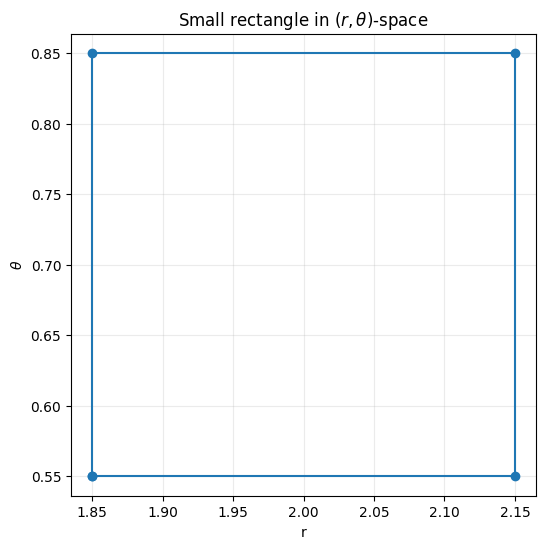

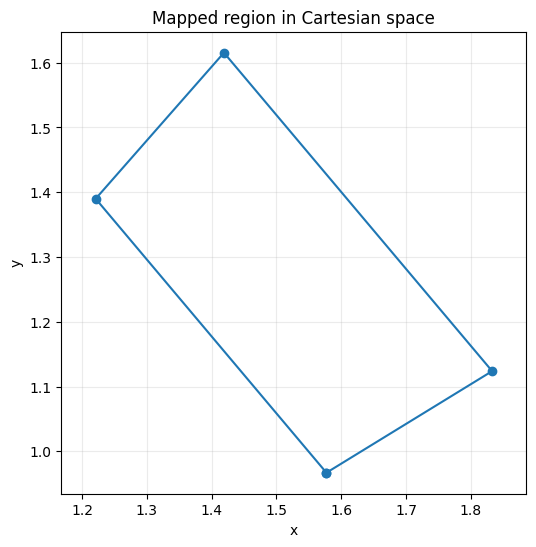

Input rectangle area: 0.09
Jacobian determinant at center: 2.0
Estimated output area: 0.18


In [15]:
q0 = np.array([2.0, 0.7])
dr = 0.15
dtheta = 0.15

square_q = np.array([
    q0 + [-dr, -dtheta],
    q0 + [ dr, -dtheta],
    q0 + [ dr,  dtheta],
    q0 + [-dr,  dtheta],
    q0 + [-dr, -dtheta]
])

mapped_xy = np.array([polar_to_cart(qi) for qi in square_q])

plt.figure(figsize=(6, 6))
plt.plot(square_q[:,0], square_q[:,1], marker="o")
plt.xlabel("r")
plt.ylabel(r"$\theta$")
plt.title(r"Small rectangle in $(r,\theta)$-space")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(mapped_xy[:,0], mapped_xy[:,1], marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapped region in Cartesian space")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

input_area = (2*dr)*(2*dtheta)
output_area_est = abs(np.linalg.det(J_polar(q0))) * input_area
print("Input rectangle area:", input_area)
print("Jacobian determinant at center:", abs(np.linalg.det(J_polar(q0))))
print("Estimated output area:", output_area_est)

---

# Part VI. Forward-mode automatic differentiation with dual numbers

A dual number has the form

$$
a+b\varepsilon,
$$

where

$$
\varepsilon^2=0.
$$

If we evaluate a function with input

$$
x=a+1\varepsilon,
$$

then

$$
f(a+\varepsilon)=f(a)+f'(a)\varepsilon.
$$

The coefficient of $\varepsilon$ is the derivative.

## 14. A minimal dual-number class

In [16]:
class Dual:
    def __init__(self, val, der=0.0):
        self.val = float(val)
        self.der = float(der)

    def __repr__(self):
        return f"Dual(val={self.val:.6g}, der={self.der:.6g})"

    def __add__(self, other):
        other = to_dual(other)
        return Dual(self.val + other.val, self.der + other.der)

    __radd__ = __add__

    def __sub__(self, other):
        other = to_dual(other)
        return Dual(self.val - other.val, self.der - other.der)

    def __rsub__(self, other):
        other = to_dual(other)
        return Dual(other.val - self.val, other.der - self.der)

    def __mul__(self, other):
        other = to_dual(other)
        return Dual(self.val * other.val, self.der * other.val + self.val * other.der)

    __rmul__ = __mul__

    def __truediv__(self, other):
        other = to_dual(other)
        return Dual(self.val / other.val,
                    (self.der * other.val - self.val * other.der) / (other.val**2))

    def __rtruediv__(self, other):
        other = to_dual(other)
        return other.__truediv__(self)

    def __neg__(self):
        return Dual(-self.val, -self.der)

    def __pow__(self, power):
        return Dual(self.val**power, power*self.val**(power-1)*self.der)

def to_dual(x):
    if isinstance(x, Dual):
        return x
    return Dual(x, 0.0)

def dual_sin(x):
    x = to_dual(x)
    return Dual(np.sin(x.val), np.cos(x.val)*x.der)

def dual_cos(x):
    x = to_dual(x)
    return Dual(np.cos(x.val), -np.sin(x.val)*x.der)

def dual_exp(x):
    x = to_dual(x)
    return Dual(np.exp(x.val), np.exp(x.val)*x.der)

def dual_log(x):
    x = to_dual(x)
    return Dual(np.log(x.val), x.der/x.val)

print("Dual-number tools ready.")

Dual-number tools ready.


## 15. Differentiate a one-variable function automatically

Let

$$
g(x)=x^3+\sin x+e^{2x}.
$$

Evaluate at $x=0.4$ using the dual input $x=0.4+1\varepsilon$.

In [17]:
def g_dual(x):
    return x**3 + dual_sin(x) + dual_exp(2*x)

x0 = 0.4
x_dual = Dual(x0, 1.0)
result = g_dual(x_dual)

exact_derivative = 3*x0**2 + np.cos(x0) + 2*np.exp(2*x0)

print("Dual result:", result)
print("Function value:", result.val)
print("Derivative from dual number:", result.der)
print("Exact derivative:", exact_derivative)
print("Finite-difference derivative:", central_diff_1d(lambda x: x**3 + np.sin(x) + np.exp(2*x), x0))

Dual result: Dual(val=2.67896, der=5.85214)
Function value: 2.6789592708011183
Derivative from dual number: 5.852142850987821
Exact derivative: 5.852142850987821
Finite-difference derivative: 5.852142851359154


## 16. Forward-mode AD for partial derivatives

To compute a partial derivative with respect to $x$, set

$$
x=a+1\varepsilon,\qquad y=b+0\varepsilon.
$$

To compute a partial derivative with respect to $y$, set

$$
x=a+0\varepsilon,\qquad y=b+1\varepsilon.
$$

In [18]:
def f_dual_xy(x, y):
    return x**2 * y + dual_sin(y)

a, b = 1.2, 0.7

# partial with respect to x
x_dual = Dual(a, 1.0)
y_dual = Dual(b, 0.0)
fx_result = f_dual_xy(x_dual, y_dual)

# partial with respect to y
x_dual = Dual(a, 0.0)
y_dual = Dual(b, 1.0)
fy_result = f_dual_xy(x_dual, y_dual)

print("f(a,b):", fx_result.val)
print("f_x from dual numbers:", fx_result.der)
print("f_y from dual numbers:", fy_result.der)
print("Exact f_x:", 2*a*b)
print("Exact f_y:", a**2 + np.cos(b))

f(a,b): 1.652217687237691
f_x from dual numbers: 1.68
f_y from dual numbers: 2.2048421872844886
Exact f_x: 1.68
Exact f_y: 2.2048421872844886


## 17. Directional derivative with dual numbers

To compute the directional derivative in direction $\mathbf u=\langle u_1,u_2\rangle$, use

$$
x=a+u_1\varepsilon,\qquad y=b+u_2\varepsilon.
$$

The dual part is

$$
\nabla f(a,b)\cdot \mathbf u.
$$

In [19]:
a, b = 1.2, 0.7
u = unit([3, 4])

x_dual = Dual(a, u[0])
y_dual = Dual(b, u[1])
dir_result = f_dual_xy(x_dual, y_dual)

grad_exact = np.array([2*a*b, a**2 + np.cos(b)])
directional_exact = np.dot(grad_exact, u)

print("Direction u:", u)
print("Directional derivative from dual numbers:", dir_result.der)
print("Gradient dot u:", directional_exact)

Direction u: [0.6 0.8]
Directional derivative from dual numbers: 2.771873749827591
Gradient dot u: 2.771873749827591


---

# Part VII. Reverse-mode automatic differentiation

Forward-mode AD is efficient for functions with few inputs and many outputs.  
Reverse-mode AD is efficient for functions with many inputs and one scalar output.

Reverse-mode AD is the core of backpropagation.

We now implement a tiny reverse-mode AD engine for scalar expressions.

## 18. A small computational graph engine

This is a simplified educational version.  
Each `Value` stores:

- a numerical value;
- a gradient;
- links to previous values;
- a local backward rule.

In [20]:
class Value:
    def __init__(self, data, _children=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data:.6g}, grad={self.grad:.6g})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    __radd__ = __add__

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    __rmul__ = __mul__

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**(-1)

    def __rtruediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return other * self**(-1)

    def __pow__(self, power):
        out = Value(self.data**power, (self,), f"**{power}")
        def _backward():
            self.grad += power * self.data**(power - 1) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(np.exp(self.data), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def sin(self):
        out = Value(np.sin(self.data), (self,), "sin")
        def _backward():
            self.grad += np.cos(self.data) * out.grad
        out._backward = _backward
        return out

    def cos(self):
        out = Value(np.cos(self.data), (self,), "cos")
        def _backward():
            self.grad += -np.sin(self.data) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)

        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

print("Reverse-mode AD engine ready.")

Reverse-mode AD engine ready.


## 19. Reverse-mode example

Let

$$
f(x,y)=x^2y+\sin y.
$$

Compute the gradient at $(x,y)=(1.2,0.7)$.

In [21]:
x = Value(1.2)
y = Value(0.7)

out = x**2 * y + y.sin()
out.backward()

print("output:", out)
print("x:", x)
print("y:", y)

print("Exact f_x:", 2*1.2*0.7)
print("Exact f_y:", 1.2**2 + np.cos(0.7))

output: Value(data=1.65222, grad=1)
x: Value(data=1.2, grad=1.68)
y: Value(data=0.7, grad=2.20484)
Exact f_x: 1.68
Exact f_y: 2.2048421872844886


## 20. Why reverse mode is useful

The scalar output had two inputs.  
One backward pass computed both partial derivatives.

For a function with thousands or millions of parameters, reverse-mode AD can still compute the gradient of one scalar loss in one backward pass.

---

# Part VIII. Backpropagation for a tiny model

Consider a simple model with one input $x$:

$$
\widehat y=w_2\tanh(w_1x+b_1)+b_2.
$$

For one data point, use squared error loss:

$$
L=(\widehat y-y)^2.
$$

We compute gradients with respect to $w_1,b_1,w_2,b_2$ using reverse-mode AD.

## 21. One-point neural-network-like computation

In [22]:
def tiny_model_loss_value(x_input, y_true, w1, b1, w2, b2):
    z = w1*x_input + b1
    a = z.tanh()
    yhat = w2*a + b2
    loss = (yhat - y_true)**2
    return loss, yhat

x_input = 1.5
y_true = 0.8

w1 = Value(0.4)
b1 = Value(-0.1)
w2 = Value(1.2)
b2 = Value(0.05)

loss, yhat = tiny_model_loss_value(x_input, y_true, w1, b1, w2, b2)
loss.backward()

print("prediction:", yhat.data)
print("loss:", loss.data)
print("grad w1:", w1.grad)
print("grad b1:", b1.grad)
print("grad w2:", w2.grad)
print("grad b2:", b2.grad)

prediction: 0.6045405887120118
loss: 0.03820438146104696
grad w1: -0.5533869992194553
grad b1: -0.3689246661463036
grad w2: -0.18065029500824042
grad b2: -0.39091882257597654


## 22. Check gradients by finite differences

We compare the reverse-mode gradients with numerical finite differences.

In [23]:
def tiny_loss_numeric(params):
    w1, b1, w2, b2 = params
    z = w1*x_input + b1
    a = np.tanh(z)
    yhat = w2*a + b2
    return (yhat - y_true)**2

params = np.array([0.4, -0.1, 1.2, 0.05], dtype=float)
grad_num = finite_jacobian(lambda p: np.array([tiny_loss_numeric(p)]), params)[0]
grad_ad = np.array([w1.grad, b1.grad, w2.grad, b2.grad])

print("AD gradient:", grad_ad)
print("Finite-difference gradient:", grad_num)
print("Difference:", grad_num - grad_ad)

AD gradient: [-0.553387 -0.368925 -0.18065  -0.390919]
Finite-difference gradient: [-0.553387 -0.368925 -0.18065  -0.390919]
Difference: [-0. -0. -0. -0.]


## 23. Gradient descent using the tiny AD engine

We fit the four parameters to one point.  
This is not a realistic learning problem, but it shows how automatic differentiation supplies gradients.

Final prediction: 0.8
Final parameters: [np.float64(0.46885429752070346), np.float64(-0.05409713498619767), 1.2248990167038882, 0.10043494631025734]
Final loss: 0.0


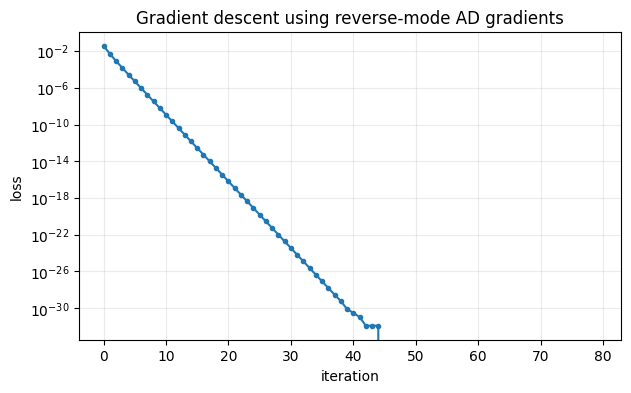

In [24]:
def train_one_point(steps=80, eta=0.08):
    w1 = Value(0.4)
    b1 = Value(-0.1)
    w2 = Value(1.2)
    b2 = Value(0.05)
    losses = []

    for k in range(steps):
        loss, yhat = tiny_model_loss_value(x_input, y_true, w1, b1, w2, b2)
        loss.backward()
        losses.append(loss.data)

        for param in [w1, b1, w2, b2]:
            param.data -= eta * param.grad
            param.grad = 0.0

    final_loss, final_yhat = tiny_model_loss_value(x_input, y_true, w1, b1, w2, b2)
    return losses, final_yhat.data, [w1.data, b1.data, w2.data, b2.data]

losses, final_prediction, final_params = train_one_point()

print("Final prediction:", final_prediction)
print("Final parameters:", final_params)
print("Final loss:", losses[-1])

plt.figure(figsize=(7, 4))
plt.plot(losses, marker="o", markersize=3)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Gradient descent using reverse-mode AD gradients")
plt.yscale("log")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IX. Jacobians in data transformations

Suppose a feature vector is transformed by a map

$$
T:\mathbb R^2\to\mathbb R^2.
$$

The Jacobian describes the local change of features.  
This is important in robotics, probability transformations, normalizing flows, optimization, and differential geometry.

## 24. Nonlinear feature map

Let

$$
T(x,y)=
\begin{bmatrix}
x+y^2\\
\sin x+e^y
\end{bmatrix}.
$$

Then

$$
J_T(x,y)=
\begin{bmatrix}
1 & 2y\\
\cos x & e^y
\end{bmatrix}.
$$

In [25]:
def T_feature(p):
    x, y = p
    return np.array([x + y**2, np.sin(x) + np.exp(y)], dtype=float)

def J_T_feature(p):
    x, y = p
    return np.array([
        [1.0, 2*y],
        [np.cos(x), np.exp(y)]
    ], dtype=float)

p = np.array([0.6, -0.4])
J_exact = J_T_feature(p)
J_num = finite_jacobian(T_feature, p)

print("Point:", p)
print("T(p):", T_feature(p))
print("Exact Jacobian:")
print(J_exact)
print("Numerical Jacobian:")
print(J_num)
print("Determinant:", np.linalg.det(J_exact))

Point: [ 0.6 -0.4]
T(p): [0.76     1.234963]
Exact Jacobian:
[[ 1.       -0.8     ]
 [ 0.825336  0.67032 ]]
Numerical Jacobian:
[[ 1.       -0.8     ]
 [ 0.825336  0.67032 ]]
Determinant: 1.330588537963382


## 25. Local grid deformation

The Jacobian approximates how a small grid near $p$ is transformed.

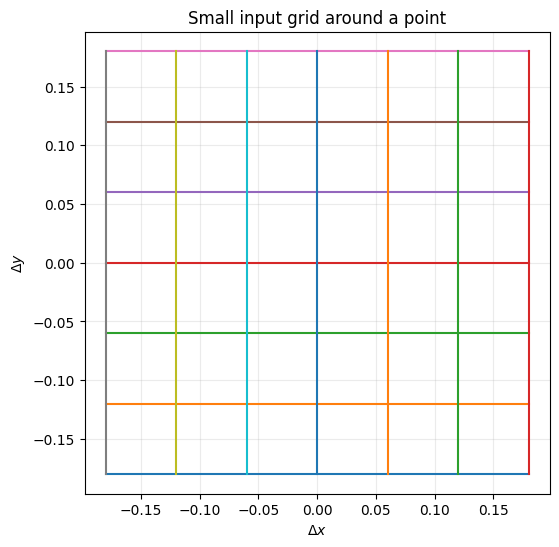

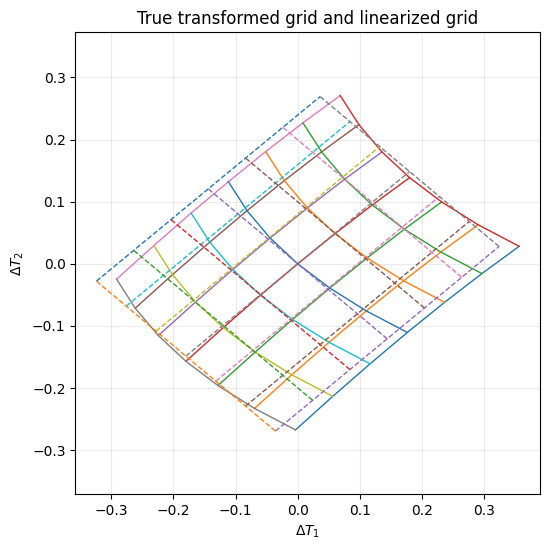

In [26]:
p = np.array([0.6, -0.4])
J = J_T_feature(p)
T0 = T_feature(p)

grid_vals = np.linspace(-0.18, 0.18, 7)
segments_input = []
segments_true = []
segments_linear = []

# horizontal small grid segments
for yy in grid_vals:
    pts = np.column_stack([grid_vals, np.full_like(grid_vals, yy)])
    segments_input.append(pts)
    segments_true.append(np.array([T_feature(p + d) - T0 for d in pts]))
    segments_linear.append(pts @ J.T)

# vertical small grid segments
for xx in grid_vals:
    pts = np.column_stack([np.full_like(grid_vals, xx), grid_vals])
    segments_input.append(pts)
    segments_true.append(np.array([T_feature(p + d) - T0 for d in pts]))
    segments_linear.append(pts @ J.T)

plt.figure(figsize=(6, 6))
for seg in segments_input:
    plt.plot(seg[:,0], seg[:,1])
plt.xlabel(r"$\Delta x$")
plt.ylabel(r"$\Delta y$")
plt.title("Small input grid around a point")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(6, 6))
for seg in segments_true:
    plt.plot(seg[:,0], seg[:,1], linewidth=1)
for seg in segments_linear:
    plt.plot(seg[:,0], seg[:,1], linestyle="--", linewidth=1)
plt.xlabel(r"$\Delta T_1$")
plt.ylabel(r"$\Delta T_2$")
plt.title("True transformed grid and linearized grid")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part X. Chapter mini-project: build and test a derivative pipeline

You will build a small pipeline

$$
\mathbf u
\mapsto G(\mathbf u)
\mapsto F(G(\mathbf u))
\mapsto L(F(G(\mathbf u))).
$$

The final output is a scalar loss.  
The goal is to compute the gradient of the loss with respect to the original input.

## 26. Define the pipeline

Let

$$
G(s,t)=
\begin{bmatrix}
s+t\\
st\\
e^s
\end{bmatrix},
$$

$$
F(x,y,z)=
\begin{bmatrix}
x^2+z\\
yz+\sin x
\end{bmatrix},
$$

and

$$
L(a,b)=a^2+3b^2.
$$

In [27]:
def G_pipeline(u):
    s, t = u
    return np.array([s + t, s*t, np.exp(s)], dtype=float)

def J_G_pipeline(u):
    s, t = u
    return np.array([
        [1.0, 1.0],
        [t, s],
        [np.exp(s), 0.0]
    ], dtype=float)

def F_pipeline(v):
    x, y, z = v
    return np.array([x**2 + z, y*z + np.sin(x)], dtype=float)

def J_F_pipeline(v):
    x, y, z = v
    return np.array([
        [2*x, 0.0, 1.0],
        [np.cos(x), z, y]
    ], dtype=float)

def L_pipeline(w):
    a, b = w
    return a**2 + 3*b**2

def grad_L_pipeline(w):
    a, b = w
    return np.array([2*a, 6*b], dtype=float)

def full_pipeline(u):
    return L_pipeline(F_pipeline(G_pipeline(u)))

def grad_full_chain(u):
    v = G_pipeline(u)
    w = F_pipeline(v)
    grad_L = grad_L_pipeline(w)      # shape (2,)
    JF = J_F_pipeline(v)             # shape (2,3)
    JG = J_G_pipeline(u)             # shape (3,2)
    return grad_L @ JF @ JG          # shape (2,)

u0 = np.array([0.3, -0.8])
print("u0 =", u0)
print("G(u0) =", G_pipeline(u0))
print("F(G(u0)) =", F_pipeline(G_pipeline(u0)))
print("L(F(G(u0))) =", full_pipeline(u0))
print("Gradient by chained Jacobians:", grad_full_chain(u0))

u0 = [ 0.3 -0.8]
G(u0) = [-0.5      -0.24      1.349859]
F(G(u0)) = [ 1.599859 -0.803392]
L(F(G(u0))) = 4.4958626457247055
Gradient by chained Jacobians: [ 3.656258 -9.38201 ]


## 27. Check the pipeline gradient by finite differences

In [28]:
grad_num = finite_jacobian(lambda u: np.array([full_pipeline(u)]), u0)[0]
grad_chain = grad_full_chain(u0)

print("Gradient by chain rule:", grad_chain)
print("Gradient by finite differences:", grad_num)
print("Difference:", grad_num - grad_chain)

Gradient by chain rule: [ 3.656258 -9.38201 ]
Gradient by finite differences: [ 3.656258 -9.38201 ]
Difference: [0. 0.]


## 28. Descent using the pipeline gradient

Use the gradient of the full composed loss to decrease the loss with respect to the original input $\mathbf u=(s,t)$.

Initial u: [ 0.3 -0.8]
Final u: [-0.515737  0.592265]
Initial loss: 4.4958626457247055
Final loss: 0.3971664395709493


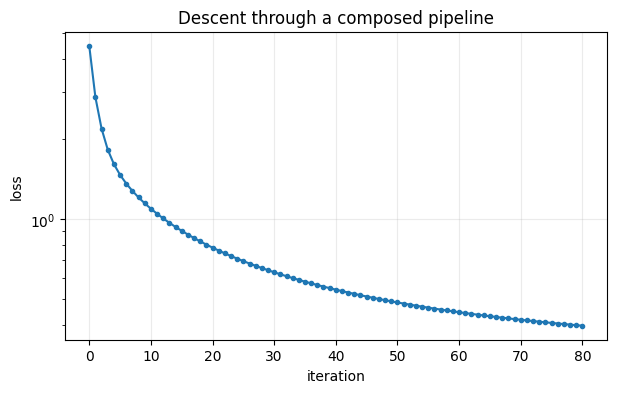

In [29]:
u = np.array([0.3, -0.8], dtype=float)
eta = 0.02
path = [u.copy()]
losses = [full_pipeline(u)]

for k in range(80):
    g = grad_full_chain(u)
    u = u - eta*g
    path.append(u.copy())
    losses.append(full_pipeline(u))

path = np.array(path)
losses = np.array(losses)

print("Initial u:", path[0])
print("Final u:", path[-1])
print("Initial loss:", losses[0])
print("Final loss:", losses[-1])

plt.figure(figsize=(7, 4))
plt.plot(losses, marker="o", markersize=3)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Descent through a composed pipeline")
plt.yscale("log")
plt.grid(True, alpha=0.25)
plt.show()

## 29. Mini-project questions

Answer the following in a markdown cell:

1. What are the dimensions of $J_G$, $J_F$, and $\nabla L$?
2. Why is the product $\nabla L\,J_F\,J_G$ valid?
3. Which variables are intermediate variables?
4. What does the gradient with respect to $(s,t)$ mean?
5. How is this pipeline similar to a neural network?

In [30]:
v = G_pipeline(u0)
w = F_pipeline(v)

print("J_G shape:", J_G_pipeline(u0).shape)
print("J_F shape:", J_F_pipeline(v).shape)
print("grad L shape:", grad_L_pipeline(w).shape)
print("Final gradient shape:", grad_full_chain(u0).shape)

J_G shape: (3, 2)
J_F shape: (2, 3)
grad L shape: (2,)
Final gradient shape: (2,)


---

# Part XI. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Chain rule along a path

Let

$$
f(x,y)=e^{xy},\qquad x(t)=t^2,\qquad y(t)=\sin t.
$$

Compute $dz/dt$ at $t=1$ by the chain rule and by finite differences.

In [31]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [32]:
def f_A(x, y):
    return np.exp(x*y)

def fx_A(x, y):
    return y*np.exp(x*y)

def fy_A(x, y):
    return x*np.exp(x*y)

def z_A(t):
    return f_A(t**2, np.sin(t))

def dz_A_chain(t):
    x = t**2
    y = np.sin(t)
    xp = 2*t
    yp = np.cos(t)
    return fx_A(x, y)*xp + fy_A(x, y)*yp

t0 = 1.0
print("Chain rule derivative:", dz_A_chain(t0))
print("Finite-difference derivative:", central_diff_1d(z_A, t0))

Chain rule derivative: 5.157430545949815
Finite-difference derivative: 5.157430547053643


## Exercise B. Jacobian

Let

$$
F(x,y,z)=
\begin{bmatrix}
xy+z\\
x^2+y^2+z^2
\end{bmatrix}.
$$

Compute the Jacobian at $(1,-1,2)$ and compare with finite differences.

In [33]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [34]:
def F_B(p):
    x, y, z = p
    return np.array([x*y + z, x**2 + y**2 + z**2], dtype=float)

def J_B(p):
    x, y, z = p
    return np.array([
        [y, x, 1],
        [2*x, 2*y, 2*z]
    ], dtype=float)

pB = np.array([1.0, -1.0, 2.0])
print("Exact Jacobian:")
print(J_B(pB))
print("Finite-difference Jacobian:")
print(finite_jacobian(F_B, pB))

Exact Jacobian:
[[-1.  1.  1.]
 [ 2. -2.  4.]]
Finite-difference Jacobian:
[[-1.  1.  1.]
 [ 2. -2.  4.]]


## Exercise C. Matrix chain rule

Let

$$
G(u,v)=(u+v,u-v,uv)
$$

and let $F$ be the function from Exercise B. Compute $J_{F\circ G}(1,2)$ using the matrix chain rule.

In [35]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [36]:
def G_C(q):
    u, v = q
    return np.array([u + v, u - v, u*v], dtype=float)

def J_G_C(q):
    u, v = q
    return np.array([
        [1, 1],
        [1, -1],
        [v, u]
    ], dtype=float)

def H_C(q):
    return F_B(G_C(q))

qC = np.array([1.0, 2.0])
J_chain_C = J_B(G_C(qC)) @ J_G_C(qC)
J_num_C = finite_jacobian(H_C, qC)

print("Chain-rule Jacobian:")
print(J_chain_C)
print("Finite-difference Jacobian:")
print(J_num_C)

Chain-rule Jacobian:
[[ 4. -3.]
 [12. 12.]]
Finite-difference Jacobian:
[[ 4. -3.]
 [12. 12.]]


## Exercise D. Dual-number derivative

Use the dual-number class to differentiate

$$
g(x)=\log(x)+x^2\sin x
$$

at $x=2$.

In [37]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [38]:
def g_D_dual(x):
    return dual_log(x) + (x**2)*dual_sin(x)

xD = Dual(2.0, 1.0)
resD = g_D_dual(xD)

exact_D = 1/2 + 2*2*np.sin(2) + 2**2*np.cos(2)

print("Dual-number result:", resD)
print("Exact derivative:", exact_D)

Dual-number result: Dual(val=4.33034, der=2.4726)
Exact derivative: 2.4726023611141574


## Exercise E. Reverse-mode gradient

Use the `Value` class to compute the gradient of

$$
f(x,y,z)=xy+\tanh(yz)+z^2
$$

at $(1,2,-1)$.

In [39]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [40]:
x = Value(1.0)
y = Value(2.0)
z = Value(-1.0)

out = x*y + (y*z).tanh() + z**2
out.backward()

print("Output:", out.data)
print("df/dx:", x.grad)
print("df/dy:", y.grad)
print("df/dz:", z.grad)

# Finite-difference check
def f_E_num(p):
    x, y, z = p
    return x*y + np.tanh(y*z) + z**2

pE = np.array([1.0, 2.0, -1.0])
gradE_num = finite_jacobian(lambda p: np.array([f_E_num(p)]), pE)[0]
print("Finite-difference gradient:", gradE_num)

Output: 2.035972419924183
df/dx: 2.0
df/dy: 0.9293491751468356
df/dz: -1.8586983502936711
Finite-difference gradient: [ 2.        0.929349 -1.858698]


---

# Formula summary

## Chain rule along a path

$$
\frac{d}{dt}f(x(t),y(t))
=
f_xx'(t)+f_yy'(t)
=
\nabla f(\mathbf r(t))\cdot \mathbf r'(t).
$$

## Jacobian matrix

For $F:\mathbb R^n\to\mathbb R^m$,

$$
J_F=
\left[
\frac{\partial F_i}{\partial x_j}
\right]_{m\times n}.
$$

## Matrix chain rule

If $H=F\circ G$, then

$$
J_H(x)=J_F(G(x))J_G(x).
$$

## Polar Jacobian

$$
\frac{\partial(x,y)}{\partial(r,\theta)}
=
\begin{bmatrix}
\cos\theta & -r\sin\theta\\
\sin\theta & r\cos\theta
\end{bmatrix},
\qquad
\det J=r.
$$

## Forward-mode AD idea

$$
f(a+\varepsilon)=f(a)+f'(a)\varepsilon.
$$

## Reverse-mode AD idea

A scalar output initializes gradient $1$ and propagates sensitivities backward through a computational graph.

# End of Chapter 10 Lab

You have used Python to explore:

- the multivariable chain rule,
- path derivatives,
- Jacobian matrices,
- matrix chain rules,
- coordinate-change Jacobians,
- finite-difference derivative checks,
- forward-mode automatic differentiation,
- reverse-mode automatic differentiation,
- backpropagation for a small model,
- and gradients through a composed pipeline.

These ideas are foundational for change of variables, implicit differentiation, optimization, neural networks, and modern scientific computing.